# Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import scanpy as sc 
import pygenelab as pgl
import decoupler as dc
import pandas as pd
from scipy.stats import rankdata
import matplotlib.pyplot as plt

# Util Functions

In [3]:
def cliffs_delta(x, y):
    """
    calculate cliff's delta between two groups
    """

    # cliffs_delta
    # api:
    # cliffs_delta(
    #     x=om6_scores,
    #     y=om9_scores,
    # )

    # remove missing values
    x = pd.Series(x).dropna().to_numpy()
    y = pd.Series(y).dropna().to_numpy()

    nx = len(x)
    ny = len(y)

    # return nan if either group is empty
    if nx == 0 or ny == 0:
        return float("nan")

    # rank all values together
    ranks = rankdata(list(x) + list(y))

    # get ranks for first group
    x_ranks = ranks[:nx]

    # mann-whitney u for first group
    u = x_ranks.sum() - nx * (nx + 1) / 2

    # convert u to cliff's delta
    delta = (2 * u / (nx * ny)) - 1

    return delta

In [4]:
def save_df_table_image(
    df,
    output_path=None,
    index=False,
    round_digits=4,
    font_size=10,
    row_height=0.5,
    min_col_width=0.08,
    max_col_width=0.45
):
    """
    create a dataframe table image and optionally save it
    """

    # save_df_table_image
    # api:
    # fig = save_df_table_image(
    #     df=cliffs_df,
    #     output_path="Output/cliffs_table.png",
    # )

    # copy df so original is not changed
    df_to_show = df.copy()

    # round numeric columns
    numeric_cols = df_to_show.select_dtypes(include="number").columns
    df_to_show[numeric_cols] = df_to_show[numeric_cols].round(round_digits)

    # include index if requested
    if index:
        df_to_show = df_to_show.reset_index()

    # convert everything to string for display
    df_display = df_to_show.astype(str)

    # get table shape
    nrows, ncols = df_display.shape

    # compute column widths from max text length
    col_lengths = []
    for col in df_display.columns:
        max_cell_len = df_display[col].map(len).max()
        header_len = len(str(col))
        col_lengths.append(max(max_cell_len, header_len))

    total_len = sum(col_lengths)

    # normalized widths
    col_widths = []
    for length in col_lengths:
        width = length / total_len
        width = max(min_col_width, width)
        width = min(max_col_width, width)
        col_widths.append(width)

    # renormalize so widths sum to about 1
    width_sum = sum(col_widths)
    col_widths = [w / width_sum for w in col_widths]

    # figure size
    fig_width = max(12, sum(col_lengths) * 0.18)
    fig_height = max(2.5, (nrows + 1) * row_height)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    # create table
    table = ax.table(
        cellText=df_display.values,
        colLabels=df_display.columns,
        cellLoc="center",
        loc="center",
        bbox=[0, 0, 1, 1]
    )

    # base style
    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(1, 1.4)

    # style cells
    for (row, col), cell in table.get_celld().items():
        # set per-column widths
        cell.set_width(col_widths[col])

        # header row
        if row == 0:
            cell.set_text_props(weight="bold")

        # left align first column for long pathway names
        if col == 0 and row > 0:
            cell.get_text().set_ha("left")
            cell.PAD = 0.01

    plt.tight_layout()

    # save only if path is provided
    if output_path is not None:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    return fig

In [25]:
def calculate_score_cliffs_delta(
    adata,
    score_col,
    group_col="sample",
    group1="OM6",
    group2="OM9",
    dropna=True
):
    """
    calculate cliff's delta for one obs score column between two groups
    """

    # calculate_obs_score_cliffs_delta
    # api:
    # result_df, group_score_df = calculate_obs_score_cliffs_delta(
    #     adata=adata,
    #     score_col="GOBP_PYRUVATE_METABOLIC_PROCESS",
    #     group_col="sample",
    #     group1="OM6",
    #     group2="OM9",
    # )

    # check required columns
    if group_col not in adata.obs.columns:
        raise ValueError(f"{group_col} not found in adata.obs")

    if score_col not in adata.obs.columns:
        raise ValueError(f"{score_col} not found in adata.obs")

    # prepare cell-level score dataframe
    group_score_df = adata.obs[[group_col, score_col]].copy()

    # remove missing values
    if dropna:
        group_score_df = group_score_df.dropna(subset=[group_col, score_col])

    # add pathway name
    group_score_df["pathway"] = score_col

    # get group scores
    group1_scores = group_score_df.loc[
        group_score_df[group_col] == group1,
        score_col
    ]

    group2_scores = group_score_df.loc[
        group_score_df[group_col] == group2,
        score_col
    ]

    # calculate cliff's delta
    delta = cliffs_delta(
        x=group1_scores,
        y=group2_scores
    )

    # decide direction
    if delta > 0:
        higher_group = group1
    elif delta < 0:
        higher_group = group2
    else:
        higher_group = "similar"

    # store result
    result = {
        "score_col": score_col,

        f"{group1}_count": group1_scores.dropna().shape[0],
        f"{group2}_count": group2_scores.dropna().shape[0],

        f"{group1}_mean": group1_scores.mean(),
        f"{group2}_mean": group2_scores.mean(),

        f"{group1}_median": group1_scores.median(),
        f"{group2}_median": group2_scores.median(),

        f"{group1}_std": group1_scores.std(),
        f"{group2}_std": group2_scores.std(),

        f"{group1}_min": group1_scores.min(),
        f"{group2}_min": group2_scores.min(),

        f"{group1}_max": group1_scores.max(),
        f"{group2}_max": group2_scores.max(),

        "mean_difference": group1_scores.mean() - group2_scores.mean(),
        "median_difference": group1_scores.median() - group2_scores.median(),

        "cliffs_delta": delta,
        "abs_cliffs_delta": abs(delta),
        "higher_group": higher_group
    }

    # convert result to dataframe
    result_df = pd.DataFrame([result])

    return result_df, group_score_df

# Get Dataset

In [5]:
# female human skeletal muscle path
FEMALE_HUMAN_SKM_PATH = "/ocean/projects/cis240075p/asachan/datasets/TA_muscle/public_datasets/SKM_multimodal_ageing/objects/tmp/myofibers_female.h5ad"

# load adata
adata = sc.read_h5ad(FEMALE_HUMAN_SKM_PATH)

# only keep OM6 and OM9
adata = pgl.subset_adata_by_obs(adata, filters={"sample": ["OM6", "OM9"]})
display(adata.obs["sample"].value_counts())

sample
OM9    40449
OM6    11429
Name: count, dtype: int64

# Get Geneset

In [11]:
# custom atrophy pathway

custom_atrophy_genes = [
    "UBB", "UBC", "FBXO32", "TRIM63", "MDM2", "FBXO30", "CAMK2B", "TIE1",
    "PSMA1", "PSMA2", "PSMA3", "PSMA4", "PSMA5", "PSMA6", "PSMA7",
    "PSMB1", "PSMB2", "PSMB3", "PSMB4", "FBXO21", "FBXO31", "NEDD4",
    "UBE2B", "UBE2G1", "UBE2J1", "CTSL", "CTSV", "BNIP3", "DEPP1",
    "GABARAPL1", "MAP1LC3", "RETREG1", "SQSTM1", "CAPN1", "CAPN2",
    "ATF4", "FOXO1", "FOXO3A", "HDAC9", "RUNX1", "AMPD3", "CHRNA1",
    "CDKN1A"
]

pathway = "Atrophy_Pathway_(PMID: 31325479)"

# convert human-style uppercase symbols to mouse-style title case
custom_atrophy_genes_human = [gene.upper() for gene in custom_atrophy_genes]

# create decoupler input dataframe
atrophy_pathway_genes = pd.DataFrame({
    "source": pathway,
    "target": custom_atrophy_genes_human
})

In [12]:
atrophy_pathway_genes.head()

,source,target
0,Atrophy_Pathway_(PMID: 31325479),UBB
1,Atrophy_Pathway_(PMID: 31325479),UBC
2,Atrophy_Pathway_(PMID: 31325479),FBXO32
3,Atrophy_Pathway_(PMID: 31325479),TRIM63
4,Atrophy_Pathway_(PMID: 31325479),MDM2


In [13]:
# check if genes are in adata
pgl.check_genes_in_adata(atrophy_pathway_genes, adata)

{'total_genes_checked': 43,
 'genes_found_in_adata': 41,
 'genes_missing_from_adata': 2,
 'matched_genes': ['UBB',
  'UBC',
  'FBXO32',
  'TRIM63',
  'MDM2',
  'FBXO30',
  'CAMK2B',
  'TIE1',
  'PSMA1',
  'PSMA2',
  'PSMA3',
  'PSMA4',
  'PSMA5',
  'PSMA6',
  'PSMA7',
  'PSMB1',
  'PSMB2',
  'PSMB3',
  'PSMB4',
  'FBXO21',
  'FBXO31',
  'NEDD4',
  'UBE2B',
  'UBE2G1',
  'UBE2J1',
  'CTSL',
  'CTSV',
  'BNIP3',
  'DEPP1',
  'GABARAPL1',
  'RETREG1',
  'SQSTM1',
  'CAPN1',
  'CAPN2',
  'ATF4',
  'FOXO1',
  'HDAC9',
  'RUNX1',
  'AMPD3',
  'CHRNA1',
  'CDKN1A'],
 'missing_genes': ['MAP1LC3', 'FOXO3A']}

# Calculate Scores

In [15]:
%%time

dc.mt.aucell(
    adata,
    atrophy_pathway_genes,
    raw=False,
    verbose=True
)

2026-05-13 07:01:03 | [INFO] aucell - Running aucell
2026-05-13 07:01:03 | [INFO] Extracted omics mat with 51878 rows (observations) and 48355 columns (features)
2026-05-13 07:01:03 | [WARNING] 6429 features of mat are empty, they will be removed
2026-05-13 07:01:05 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1
2026-05-13 07:01:05 | [INFO] Network has 41 unique features and 1 unique sources
2026-05-13 07:01:05 | [INFO] aucell - calculating 1 AUCs for 41926 targets across 51878 observations, categorizing features at rank=2097
100%|██████████| 51878/51878 [00:53<00:00, 974.69it/s] 
2026-05-13 07:01:58 | [INFO] aucell - done


CPU times: user 49min 29s, sys: 1.11 s, total: 49min 30s
Wall time: 55.4 s


# Develop Plot

In [17]:
# create pathway scores column in obs
adata.obs[pathway] = adata.obsm["score_aucell"][pathway].copy()
display(adata.obs[pathway].head(10))

CELL2785_N1_1_1_6_1    0.210912
CELL1152_N1_1_1_6_1    0.179085
CELL312_N2_1_1_6_1     0.171178
CELL2659_N1_1_1_6_1    0.244419
CELL303_N2_1_1_6_1     0.193700
CELL591_N2_1_1_6_1     0.221968
CELL736_N2_1_1_6_1     0.133958
CELL531_N2_1_1_6_1     0.177769
CELL299_N2_1_1_6_1     0.212193
CELL685_N2_1_1_6_1     0.131397
Name: Atrophy_Pathway_(PMID: 31325479), dtype: float64

In [18]:
# get scores per group 
group_score_df = pgl.prepare_group_score_df(adata, group_col="sample", value_col=pathway, dropna=True)
display(group_score_df.head())

,sample,Atrophy_Pathway_(PMID: 31325479)
0,OM6,0.210912
1,OM6,0.179085
2,OM6,0.171178
3,OM6,0.244419
4,OM6,0.193700


In [19]:
# get summary of scores per group
pgl.summarize_score_by_group(group_score_df, group_col="sample", score_col=pathway)

,sample,count,mean,median,std,min,max
0,OM6,11429,0.193617,0.194323,0.047556,0.035211,0.375229
1,OM9,40449,0.190693,0.189870,0.047722,0.021453,0.406539


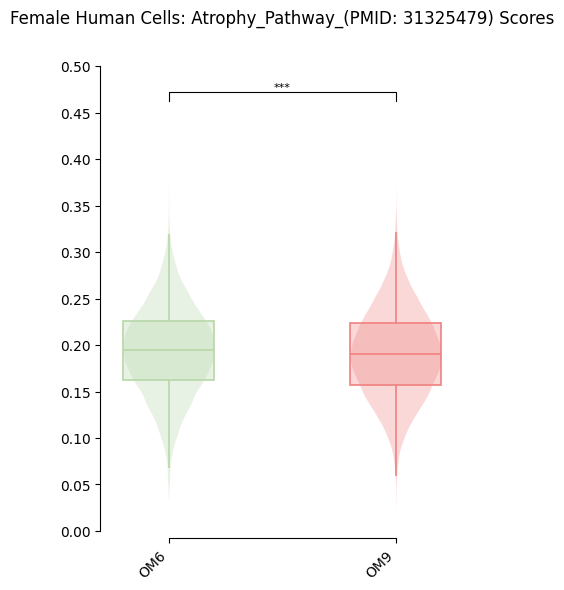

<Figure size 640x480 with 0 Axes>

In [20]:
# choose order
sample_order = ["OM6", "OM9"]

# palette keys must match age_label values
palette = {
    "OM6": "#B6D7A8",
    "OM9": "#F08080"
}

# plot violin box plot
fig_violin_box = pgl.plot_violin_box_combo(group_score_df,
                                           x_var="sample",
                                           y_var=pathway,
                                           title=f"Female Human Cells: {pathway} Scores",
                                           palette=palette,
                                           x_ticks=sample_order,
                                           show_scatter=False)

display(fig_violin_box)

In [22]:
# subset OM6 and get gene correlation
adata_om6 = pgl.subset_adata_by_obs(adata, filters={"sample": "OM6"})
ranked_genes_om6 = pgl.compute_gene_correlation_against_score(adata_om6, 
                                                              pgl.get_pathway_genes(atrophy_pathway_genes, pathway), 
                                                              score=pathway)
display(ranked_genes_om6.head())

# subset OM9 and get gene correlation
adata_om9 = pgl.subset_adata_by_obs(adata, filters={"sample": "OM9"})
ranked_genes_om9 = pgl.compute_gene_correlation_against_score(adata_om9, 
                                                              pgl.get_pathway_genes(atrophy_pathway_genes, pathway), 
                                                              score=pathway)
display(ranked_genes_om9.head())

,gene,spearman_corr,rank
0,CAMK2B,0.237283,1
1,SQSTM1,0.232607,2
2,ATF4,0.228061,3
3,UBC,0.218515,4
4,AMPD3,0.215945,5


,gene,spearman_corr,rank
0,CHRNA1,0.408347,1
1,RUNX1,0.377843,2
2,SQSTM1,0.342194,3
3,RETREG1,0.338490,4
4,ATF4,0.274781,5


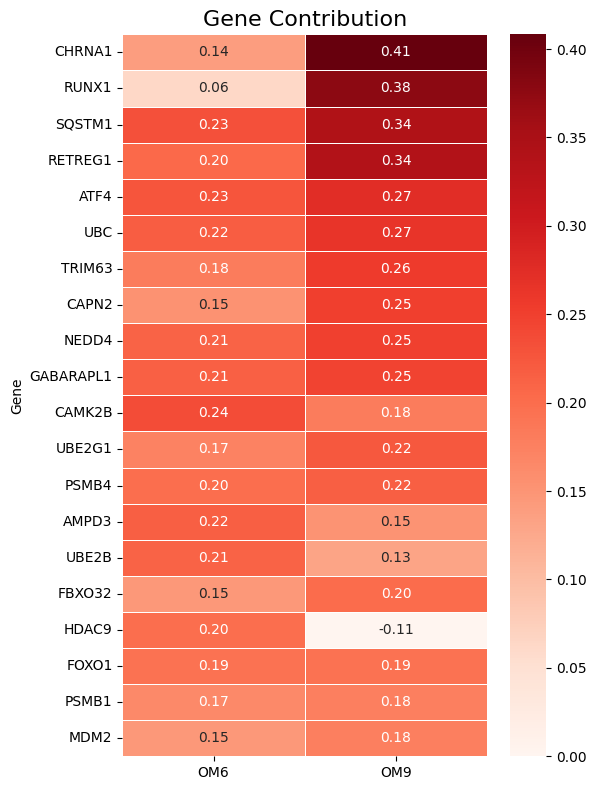

In [23]:
gene_contribution_df, fig_gene_contribution_heatmap, ax_gene_contribution = pgl.plot_gene_contribution_heatmap(
    {"OM6": ranked_genes_om6,
     "OM9": ranked_genes_om9},
     title="Gene Contribution"
)

# Save Plot

In [24]:
from pathlib import Path

# output folder
output_dir = Path("Output")
output_dir.mkdir(parents=True, exist_ok=True)

# figures to save separately
figures_to_save = {
    "Violin_Box": fig_violin_box,
    "Gene_Contribution_Heatmap": fig_gene_contribution_heatmap
}

# save each figure as svg and png
for plot_type, fig in figures_to_save.items():

    # create output paths
    svg_path = output_dir / f"OM6_OM9_{pathway}_{plot_type}_SVG.svg"
    png_path = output_dir / f"OM6_OM9_{pathway}_{plot_type}_PNG.png"

    # save editable svg
    pgl.save_editable_svg(
        fig=fig,
        output_path=svg_path
    )

    # save png
    pgl.save_fig_as_png(
        fig=fig,
        output_path=png_path
    )

    print(f"saved: {svg_path}")
    print(f"saved: {png_path}")

saved: Output/OM6_OM9_Atrophy_Pathway_(PMID: 31325479)_Violin_Box_SVG.svg
saved: Output/OM6_OM9_Atrophy_Pathway_(PMID: 31325479)_Violin_Box_PNG.png
saved: Output/OM6_OM9_Atrophy_Pathway_(PMID: 31325479)_Gene_Contribution_Heatmap_SVG.svg
saved: Output/OM6_OM9_Atrophy_Pathway_(PMID: 31325479)_Gene_Contribution_Heatmap_PNG.png


# Calculate And Save Cliffs Delta

In [ ]:
cliffs_df, group_score_df = calculate_score_cliffs_delta(adata, score_col=pathway)

In [27]:
cliffs_df

,score_col,OM6_count,OM9_count,OM6_mean,OM9_mean,OM6_median,OM9_median,OM6_std,OM9_std,OM6_min,OM9_min,OM6_max,OM9_max,mean_difference,median_difference,cliffs_delta,abs_cliffs_delta,higher_group
0,Atrophy_Pathway_(PMID: 31325479),11429,40449,0.193617,0.190693,0.194323,0.18987,0.047556,0.047722,0.035211,0.021453,0.375229,0.406539,0.002924,0.004453,0.042032,0.042032,OM6


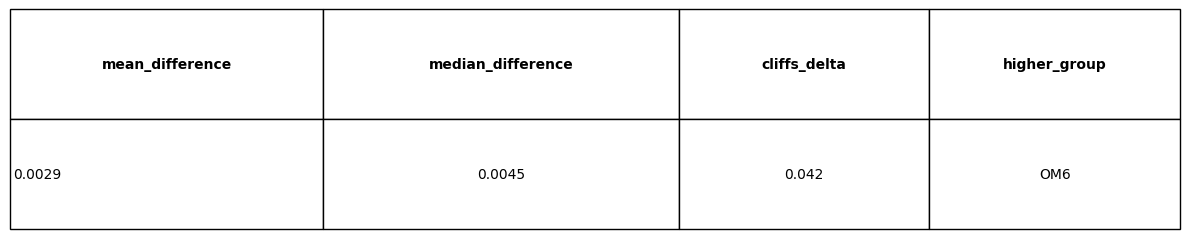

In [30]:
plot_df = cliffs_df[["mean_difference", "median_difference", "cliffs_delta", "higher_group"]]
fig_cliffs_delta_table = save_df_table_image(plot_df)

In [31]:
pgl.save_fig_as_png(fig_cliffs_delta_table, "Output/Cliffs_Delta_Atrophy_PNG.png")
pgl.save_editable_svg(fig_cliffs_delta_table, "Output/Cliffs_Delta_Atrophy_SVG.svg")

PosixPath('Output/Cliffs_Delta_Atrophy_SVG.svg')